In [3]:
# Run once to install dependencies if needed
!pip install torchinfo pytorch_lightning ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=88fdac1db8cf586e2aecebcd6578c071a2d79180bd41c5c154771e57f604c2a2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


# Lab 6: DenseNet for CIFAR-10 Image Classification

**Prithika Kandasamy, Jack Lichwa, Hemant Kumaar**

In this lab, we study the motivation and design of DenseNet architecture, compare it to standard CNN and ResNet architectures, and use transfer learning on DenseNet-121 CIFAR-10 to demonstrate its practical performance on image classification relative to these earlier models.


---

## Introduction

### Overview

As convolutional networks were scaled up to solve more complex vision tasks, researchers found that simply stacking more layers often improved performance, since deeper models can represent richer hierarchical features. However, pushing depth to dozens or even hundreds of layers exposed several structural weaknesses in standard CNN designs.

### Three Structural Barriers to Scaling Deep CNNs

As deep CNNs evolved through the early 2010s, researchers realized that network depth was critical for learning complex semantic hierarchies. However, as networks grew exceptionally deep, they encountered three structural barriers:

*   **The Vanishing Gradient Problem**: In very deep networks, gradients fade as they flow backward, so early layers stop learning effectively.
*   **The Information Bottleneck**: In sequential networks, each layer only sees the previous layer's output, so if useful details are discarded at one step, deeper layers can never recover them.
*   **Feature Redundancy & Parameter Explosion**: Because deeper layers cannot directly reuse early features, they end up relearning similar patterns and need many more channels, which causes parameter counts to grow very large in deep CNNs.

These limitations motivated new architectures, leading to the development of residual networks (ResNets).

---

### ResNet: Improving Deep CNNs with Additive Skip Connections

ResNet improves deep CNN training by introducing identity skip connections, also called shortcuts, which copy a block's input directly to its output. Instead of forcing each block to learn a completely new transformation, the block only learns a residual update added to the existing representation:

$$y = F(x) + x$$

Here, $F(x)$ is the residual update learned by the weight layers, while $x$ is forwarded unchanged through the shortcut path. This creates a direct, low-resistance route for gradient flow during backpropagation, significantly reducing the vanishing-gradient problem and allowing CNNs with dozens or even hundreds of layers to train reliably.

Importantly, ResNet does not preserve the original image through one global skip connection. Instead, each shortcut is local and only bypasses a small group of layers. As residual blocks accumulate, the network progressively builds a representation of the form:

$$x_L = x_0 + \sum_{i=0}^{L-1} F_i(x_i)$$

This means deeper layers receive a continuously refined mixture of earlier representations and newly learned feature updates. Because gradients distribute cleanly through the additive shortcut paths, optimization remains stable even in very deep architectures.

However, ResNet mainly improves optimization and gradient flow rather than fundamentally redesigning feature reuse. Because features are merged through addition, early information can still become diluted as depth increases, and deeper layers may continue relearning similar patterns. This motivated architectures such as DenseNet, which changed how features are preserved and reused across the network.

---

### DenseNet: Maximizing Feature Reuse with Dense Connectivity

DenseNet (Densely Connected Convolutional Networks), introduced by Huang et al. at CVPR 2017, builds on the shortcut concept of ResNet but shifts the core mathematical operation from addition to channel-wise concatenation. Rather than merging old and new features together, DenseNet places them side by side in an accumulating feature bank.

Within each dense block, every layer receives the outputs of all previous layers as its input. For the $l$-th layer in a dense block, the forward propagation is defined as:

$$x_l = H_l\!\left([x_0,\; x_1,\; \dots,\; x_{l-1}]\right)$$

where $[x_0, x_1, \dots, x_{l-1}]$ represents the concatenation of all prior feature maps, and $H_l$ is a composite transformation typically consisting of Batch Normalization, ReLU, and a Convolution layer.


Because features are **concatenated rather than added**, earlier representations are never overwritten — the spatial edges detected in layer 1 remain directly accessible, unchanged, at layer 24. Every layer in the block can read the entire block's history. This has three structural consequences:

- **Hyper-direct gradient flow:** Gradients flow from the loss function directly back to every preceding layer via independent paths, making vanishing gradients structurally impossible within a Dense Block.
- **Explicit feature reuse:** No layer needs to re-learn what earlier layers already encoded, allowing each layer to stay narrow (small output channel count).
- **Complementary learning:** Each layer is forced to add genuinely new information, since all prior representations are already available — redundancy is minimised by design.

The diagram below illustrates the differences between the three architectures: plain CNNs (sequential only), ResNets (local additive shortcuts), and DenseNets (dense concatenation within each block).

![](https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/DenseNet121-CFAR/main/img/features-memorize-comp.png)

> **[FIGURE 1 — Plain CNN / ResNet / DenseNet architecture comparison (3-panel)]**
> *Left: sequential plain CNN. Centre: ResNet residual blocks with additive skip connections. Right: DenseNet dense block with concatenation-based connections.*

### DenseNet: History and Standard Variants

DenseNet (Densely Connected Convolutional Networks) was introduced by **Gao Huang, Zhuang Liu, Laurens van der Maaten, and Kilian Weinberger** and presented at **CVPR 2017**, where it received the Best Paper Award.

For details, see the original paper: [arXiv version](https://arxiv.org/abs/1608.06993) · [CVPR 2017 open-access PDF](https://openaccess.thecvf.com/content_cvpr_2017/papers/Huang_Densely_Connected_Convolutional_CVPR_2017_paper.pdf) · [Official GitHub repository](https://github.com/liuzhuang13/densenet).

#### Positioning in the CNN Timeline

AlexNet (2012) proved that depth mattered for visual recognition. VGGNet (2014) pushed plain sequential stacking to 19 layers and exposed the vanishing-gradient ceiling. ResNet (2015) broke through with additive skip connections, enabling networks of 50-152 layers. Yet ResNet's element-wise addition still allowed early feature information to become diluted as depth increased, and the features were mixed rather than preserved.DenseNet's answer was to archive every intermediate representation in an ever-growing feature bank, making the entire block's history directly readable by every downstream layer.

#### Standard ImageNet Variants

All four standard models share the same stem (7x7 Conv, stride 2 -> 3x3 MaxPool), four Dense Blocks separated by three Transition Layers, and a Global Average Pooling + linear classifier head. They differ only in the number of dense layers per block:



![](https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/DenseNet121-CFAR/main/img/densnet-variations.png)

> *Source: Huang et al., CVPR 2017.*

Based on above, we will use DenseNet-121 (6/12/24/16 layers per block), which is the standard transfer-learning backbone: deep enough to carry rich ImageNet features, compact enough at ~7 M parameters to fine-tune on modest GPU hardware.

**In the rest of this lab, DenseNet-121 is the concrete example used for transfer learning and CIFAR-10 fine-tuning.**

---
## DenseNet-121 Architecture


### Pipeline Overview

Within each Dense Block, DenseNet uses a **Bottleneck Design**: every dense layer contains two weight-bearing convolutions, a 1x1 convolution that acts as a bottleneck by reducing channel width, followed by a 3x3 convolution that serves as the primary feature extractor, giving **two weight layers per dense layer**.

![](https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/DenseNet121-CFAR/main/img/DenseNet-121-Mechanics.png)

> **[FIGURE 2 — Generic DenseNet-121 Block-by-Block Mechanics]**
> *Nine-stage pipeline showing input/output shapes, channel accumulation (k=32), and weight layer counts per stage.*

### Inside a Dense Layer: Bottleneck Design

As layer index $l$ increases within a block, the concatenated input grows wider: layer $l$ receives $C_0 + k(l - 1)$ input channels, where $C_0$ is the block entry channel count and $k$ is the **growth rate**.

Without compression, the 3x3 convolution would become increasingly expensive. The **bottleneck 1x1 convolution** solves this by first compressing the concatenated input to a fixed width of $4k = 128$ channels before the 3x3 extractor.

Each dense layer therefore has exactly **two weight-bearing convolutions** and produces exactly $k = 32$ new channels. Dense layer mechanics is visualized in **Figure 2 (bottom-left dense-layer schematic)**

**Key hyperparameter:** $k = 32$ (growth rate). With $k=32$, each layer adds only 32 channels regardless of how wide the concatenated input has grown. Representational power expands linearly rather than exponentially, preventing parameter bloat. Standard ImageNet DenseNet models use growth rates of $k = 12$-$48$.

### Between Blocks: Transition Layers

Dense Blocks grow channels linearly. After Dense Block 1, the feature map has 256 channels. Without intervention, this would accumulate to impractical depths across the full backbone. **Transition Layers** sit between Dense Blocks and perform two compressions:


1. **Channel compression** — a 1x1 convolution reduces depth by a factor $\theta$:
$$C_{\text{out}} = \lfloor C_{\text{in}} x \theta \rfloor, \quad \theta = 0.5$$

2. **Spatial downsampling** — 2x2 average pooling halves height and width.

| Transition | After Block | $C_{\text{in}}$ | $\theta$ | $C_{\text{out}}$ | Spatial change |
|-----------|------------|---------|---------|---------|---------------|
| T1 | DB1 (6 layers) | 256 | 0.5 | 128 | 56x56 → 28x28 |
| T2 | DB2 (12 layers) | 512 | 0.5 | 256 | 28x28 → 14x14 |
| T3 | DB3 (24 layers) | 1024 | 0.5 | 512 | 14x14 → 7x7 |

*Note that **no transition follows Dense Block 4** — spatial resolution stays at 7x7 and channels remain at 1024 until the classification head.*

### The 121-Layer Count

Only weight-bearing layers (convolutions + linear) contribute to the model name. Each dense layer contains one 1x1 Conv and one 3x3 Conv = **2 weight layers per dense layer**.

```
Stem  (1)
+ DB1 (6  layers x 2 convs = 12)  + T1 (1)
+ DB2 (12 layers x 2 convs = 24)  + T2 (1)
+ DB3 (24 layers x 2 convs = 48)  + T3 (1)
+ DB4 (16 layers x 2 convs = 32)
+ Head Linear (1)
─────────────────────────────────────────
= 1 + 12 + 1 + 24 + 1 + 48 + 1 + 32 + 1 = 121
```

Dense Block 3 is the **parameter heavyweight**: 24 layers x 2 convolutions each = 48 weight layers, housing the majority of the backbone's ~6.95 M parameters (approximately 70,400-137,000 per layer as the concatenated input widens).

### DenseNet-121 Hyperparameters

Three hyperparameters define DenseNet-121's design space:

| Hyperparameter       | Value | Purpose |
|----------------------|-------|---------|
| Growth rate k        | 32    | Each layer adds exactly 32 new channels |
| Bottleneck width 4k  | 128   | 1x1 Conv compresses the concatenated input before each 3x3 Conv, preventing parameter explosion |
| Compression factor θ | 0.5   | Each transition layer halves channels, creating the sawtooth profile 64→256→128→512→256→1024→512→1024 |

Together these choices yield **≈7.0 M parameters**, less than 28% of ResNet-50's 25.6 M, while matching or exceeding ResNet-50 on ImageNet classification.

### Benefits: Gradient Flow and Feature Reuse

| Architecture | Gradient paths to layer $l$ | Feature preservation |
|--------------|---------------------------|----------------------|
| Plain CNN    | 1                         | Overwritten each layer |
| ResNet       | 2 (main path + skip)      | Modified by element-wise addition |
| DenseNet     | $l$ direct paths            | Fully intact — append-only |

In DenseNet, layer $l$'s output is concatenated into the input of every downstream layer in the block, so gradients flow back from the loss through $l$ independent direct paths. This dense connectivity both stabilises optimisation (many short gradient routes instead of one long chain) and reduces feature redundancy, because later layers can directly reuse earlier edge and texture detectors instead of re-learning them.

### Trade-offs: Memory and Activation Footprint

The architectural price of dense connectivity is memory: the same “feature bank” that enables reuse also has to stay in GPU memory for the entire block. A plain CNN or ResNet only needs to keep one layer's output (plus a skip) at a time, but DenseNet must store all $l$ feature maps in a block simultaneously until backprop completes. This is why, for a single 3x224x224 image, DenseNet-121 uses about **180 MB of activations** versus only **≈28 MB of parameters** — around a **6x larger activation footprint** than parameter footprint, and a much higher training-time memory cost than ResNets of comparable depth.

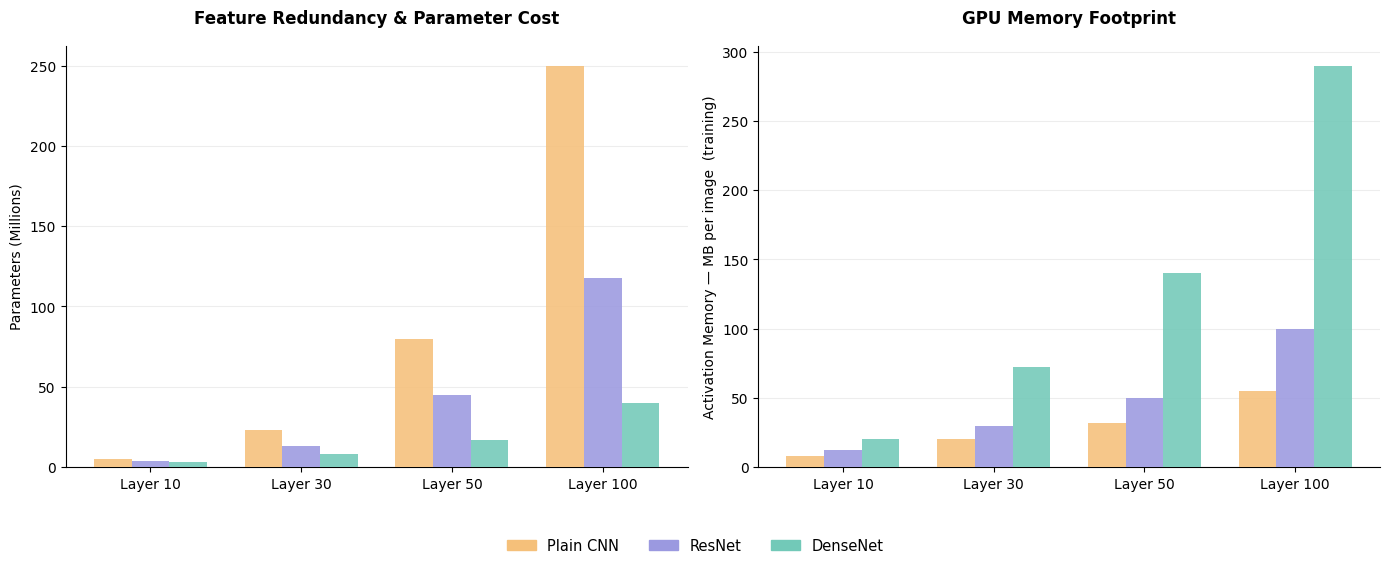

> **[FIGURE 3 — Feature Redundancy & Parameter Cost / GPU Memory Footprint]**
> *Two-panel chart. Left: parameter count scaling as network depth increases for plain CNN, ResNet, and DenseNet at 10/30/50/100 layers — DenseNet stays dramatically lower due to narrow per-layer growth (k=32) and feature reuse. Right: training activation memory (MB per image) across the same depth range — DenseNet's memory grows faster than linear as dense connectivity keeps all prior feature maps alive for the backward pass.
>

## DenseNet-121 CIFAR-10 Transfer Learning


### Libraries


In [4]:
# Uncomment if needed:
# !pip install torchinfo pytorch_lightning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam

from torchvision.datasets import CIFAR10
from torchvision.models import densenet121, DenseNet121_Weights
from torchvision.transforms import (Compose, Resize, ToTensor, Normalize,
                                    RandomHorizontalFlip, RandomResizedCrop,
                                    ColorJitter)
from torchinfo import summary

from pytorch_lightning import Trainer, seed_everything, Callback

from ISLP.torch import (SimpleDataModule, SimpleModule,
                        ErrorTracker, rec_num_workers)

seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)
max_num_workers = rec_num_workers()

INFO:lightning_fabric.utilities.seed:Seed set to 0


---
### Load and Explore Data


In [5]:
(cifar10_train_raw,
 cifar10_test_raw) = [CIFAR10(root="data", train=train, download=True)
                      for train in [True, False]]


100%|██████████| 170M/170M [00:03<00:00, 49.7MB/s]


In [6]:
NUM_CLASSES  = 10
CLASS_LABELS = cifar10_train_raw.classes

print(f"Training set size : {len(cifar10_train_raw):,} images")
print(f"Test set size     : {len(cifar10_test_raw):,} images")
print(f"Image shape       : {cifar10_train_raw.data[0].shape}  (H x W x C)")
print(f"Classes           : {CLASS_LABELS}")


Training set size : 50,000 images
Test set size     : 10,000 images
Image shape       : (32, 32, 3)  (H x W x C)
Classes           : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


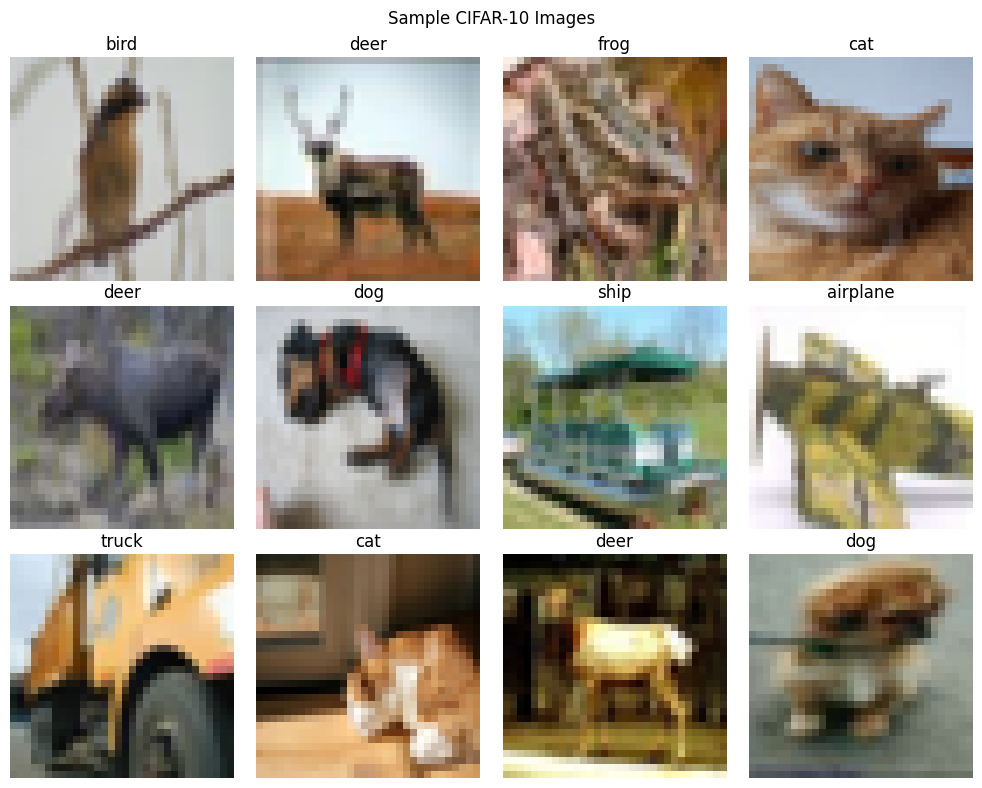

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
rng = np.random.default_rng(42)
indices = rng.choice(len(cifar10_train_raw), 12, replace=False).reshape(3, 4)

for i in range(3):
    for j in range(4):
        idx = int(indices[i, j])
        axes[i, j].imshow(cifar10_train_raw.data[idx])
        axes[i, j].set_title(CLASS_LABELS[cifar10_train_raw.targets[idx]])
        axes[i, j].axis("off")

fig.suptitle("Sample CIFAR-10 Images")
fig.tight_layout()
plt.show()


---
### Model Implementation

---
#### Dataset Preprocessing


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transform: augmentation + ImageNet normalisation
train_transform = Compose([
    RandomResizedCrop(224, scale=(0.8, 1.0)),  # random crop & resize (replaces fixed Resize)
    RandomHorizontalFlip(),                     # 50 % chance of horizontal flip
    ColorJitter(brightness=0.2, contrast=0.2,
                saturation=0.2, hue=0.1),       # randomise colour
    ToTensor(),
    Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Test transform: deterministic — no augmentation
test_transform = Compose([
    Resize(224),
    ToTensor(),
    Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

cifar_train_ds = CIFAR10(root='data', train=True,  download=False, transform=train_transform)
cifar_test_ds  = CIFAR10(root='data', train=False, download=False, transform=test_transform)

print(f"Train dataset size : {len(cifar_train_ds):,} images")
print(f"Test  dataset size : {len(cifar_test_ds):,} images")
print(f"Single image shape : {cifar_train_ds[0][0].shape}  (C, H, W)")

cifar_dm = SimpleDataModule(cifar_train_ds, cifar_test_ds,
                            validation=0.2,
                            num_workers=min(4, max_num_workers),
                            batch_size=64)

for X_batch, Y_batch in cifar_dm.train_dataloader():
    print(f"Batch X shape : {X_batch.shape}   (batch, C, H, W)")
    print(f"Batch Y shape : {Y_batch.shape}")
    break

Train dataset size : 50,000 images
Test  dataset size : 10,000 images
Single image shape : torch.Size([3, 224, 224])  (C, H, W)
Batch X shape : torch.Size([64, 3, 224, 224])   (batch, C, H, W)
Batch Y shape : torch.Size([64])


DenseNet121 was pretrained on 224x224 ImageNet images. Resizing CIFAR-10's 32x32 images to the same resolution keeps all pretrained weights valid. Applying **ImageNet normalisation** keeps activations in the range expected by the pretrained batch-norm layers.

**Training augmentation** exposes the frozen backbone to more varied crops and colours each epoch, giving the linear classifier head a richer distribution of features to fit and reducing overfitting:

| Transform | Purpose |
|---|---|
| `RandomResizedCrop(224, scale=(0.8, 1.0))` | Random crop of 80-100 % of the image, resized to 224 — teaches position invariance |
| `RandomHorizontalFlip()` | 50 % mirror — doubles effective dataset size for symmetric classes |
| `ColorJitter(0.2, 0.2, 0.2, 0.1)` | Random brightness/contrast/saturation/hue shifts — reduces colour overfitting |

The **test transform** is kept deterministic (`Resize(224)` only) so evaluation metrics are reproducible and unaffected by randomness.

#### Model Building

In [9]:
seed_everything(0, workers=True)

densenet_model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

# Classifier head: Dropout(0.3) before the linear layer to regularise
densenet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1024, NUM_CLASSES)
)

# Freeze all layers except the new classifier head
for name, param in densenet_model.named_parameters():
    param.requires_grad = ("classifier" in name)

# Keep backbone BatchNorm in eval mode so pretrained stats aren't overwritten
for module in densenet_model.features.modules():
    if isinstance(module, nn.BatchNorm2d):
        module.eval()

trainable = sum(p.numel() for p in densenet_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in densenet_model.parameters())
print(f"Trainable params : {trainable:,} / {total:,}  (head only)")

INFO:lightning_fabric.utilities.seed:Seed set to 0


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]


Trainable params : 10,250 / 6,964,106  (head only)


In [10]:
# Model summary
summary(densenet_model, input_size=(1, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DenseNet                                 [1, 3, 224, 224]          [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                         [1, 64, 112, 112]         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 64, 56, 56]           [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 64, 56, 56]           [1, 32, 56, 56]           (45,440)
│    │    └─_DenseLayer: 3-2             [1, 64, 56, 56]           [1, 32, 56, 56]           (49,600)
│    │    └─_De

**Note:** *Activations (180 MB) dominate over parameters (28 MB). Dense connectivity keeps all prior feature maps alive until a block completes. At batch size 64 activations alone exceed 11 GB.*

---
### Train the Model

**Two-Phase Fine-Tuning Strategy**

We fine-tune DenseNet-121 in two phases:

| Phase | Epochs | Layers trained | LR (backbone) | LR (head) | Purpose |
|-------|--------|---------------|--------------|----------|---------|
| 1 — Frozen | 2 | Classifier head only (~10 K params) | frozen | 1e-3 | Warm up the random head without corrupting pretrained features |
| 2 — Fine-tune | 3 | Full model (~7 M params) | 5e-5 | 1e-3 | Adapt backbone features to CIFAR-10 at a low LR |

The backbone's weights are smaller, because it is already well-trained on ImageNet. A high LR would overwrite useful low-level features. A 20x smaller LR (5e-5) nudges those features toward CIFAR-10 without destroying them. The head uses 1e-3 since it still needs to adapt.

**Parameter budget:**

| Component | Params | Share |
|-----------|--------|-------|
| Frozen backbone (features + final BN) | 6,953,856 | 99.85% |
| Trainable head (Dropout + Linear) | 10,250 | 0.15% |
| **Total** | **6,964,106** | — |

Training only 0.15% of weights is why Phase 1 converges in 2 epochs.

**Memory footprint (single 224x224 image):**

| Component | Size |
|-----------|------|
| Parameters | 27.86 MB |
| Activations (forward + backward) | 180.53 MB |
| Input tensor | 0.60 MB |
| **Estimated total** | **208.99 MB** |

Activations (180 MB) dominate over parameters (28 MB) — the memory cost of dense connectivity keeping all prior feature maps alive until each block completes. At batch size 64, activations alone exceed 11 GB, hence GPU is required.

In [17]:
class MetricsHistory(Callback):
    def __init__(self):
        self.train_loss, self.train_acc = [], []
        self.val_loss,   self.val_acc   = [], []

    def on_train_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        self.train_loss.append(m["train_loss"].item())
        self.train_acc .append(m["train_accuracy_epoch"].item())

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        m = trainer.callback_metrics
        self.val_loss.append(m["valid_loss"].item())
        self.val_acc .append(m["valid_accuracy"].item())


# ── Phase 1: head only, backbone frozen (2 epochs) ───────────────────────────
optimizer_p1 = Adam(densenet_model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

densenet_module = SimpleModule.classification(densenet_model,
                                              num_classes=NUM_CLASSES,
                                              optimizer=optimizer_p1)

hist_p1 = MetricsHistory()
trainer_p1 = Trainer(deterministic=True,
                     max_epochs=2,
                     enable_progress_bar=True,
                     enable_model_summary=False,
                     callbacks=[ErrorTracker(), hist_p1])

trainer_p1.fit(densenet_module, datamodule=cifar_dm)

# ── Phase 2: unfreeze all layers (3 epochs) ───────────────────────────────────
for param in densenet_model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in densenet_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in densenet_model.parameters())
print(f"\nPhase 2 — trainable params: {trainable:,} / {total:,}  (full model)")

optimizer_p2 = Adam([
    {"params": densenet_model.features.parameters(),    "lr": 5e-5, "weight_decay": 1e-4},
    {"params": densenet_model.classifier.parameters(),  "lr": 1e-3, "weight_decay": 1e-4},
])

densenet_module_ft = SimpleModule.classification(densenet_model,
                                                  num_classes=NUM_CLASSES,
                                                  optimizer=optimizer_p2)

hist_p2 = MetricsHistory()
trainer_p2 = Trainer(deterministic=True,
                     max_epochs=3,
                     enable_progress_bar=True,
                     enable_model_summary=False,
                     callbacks=[ErrorTracker(), hist_p2])

trainer_p2.fit(densenet_module_ft, datamodule=cifar_dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Phase 2 — trainable params: 6,964,106 / 6,964,106  (full model)


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


#### Training vs. Validation Plot

**Training** metrics are computed on the data the model is actively learning from each epoch — the model has seen these examples and adjusted its weights based on them, so it tends to look optimistically good.

**Validation** metrics are computed on a held-out 20% of data the model never trains on. This is the honest signal: it tells you how well the model generalises to new examples.


**General Guidelines**:

| Scenario | What you see | What it means |
|---|---|---|
| Train ≈ Validation | Lines track closely | Good generalisation, no overfitting |
| Train down but Validation up | Lines diverge | Overfitting — memorising training data |
| Both high loss / low acc | Lines stay flat | Underfitting — model not learning |


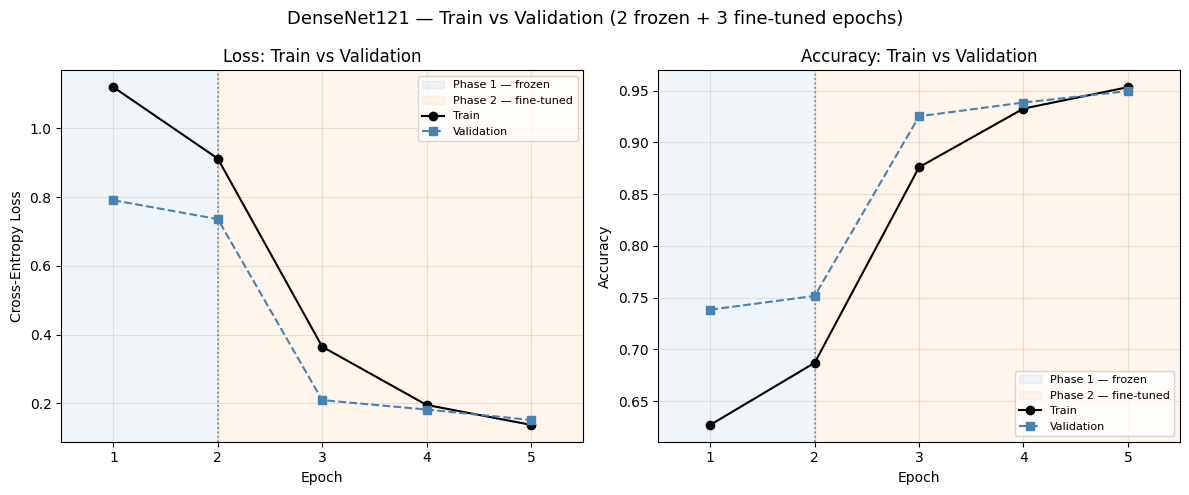

In [18]:
# Build combined epoch lists (phase 1 = 1-2, phase 2 = 3-5)
epochs_p1 = list(range(1, 3))
epochs_p2 = list(range(3, 6))
all_epochs     = epochs_p1 + epochs_p2
all_train_loss = hist_p1.train_loss + hist_p2.train_loss
all_train_acc  = hist_p1.train_acc  + hist_p2.train_acc
all_val_loss   = hist_p1.val_loss   + hist_p2.val_loss
all_val_acc    = hist_p1.val_acc    + hist_p2.val_acc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, train_vals, val_vals, ylabel, title in [
    (ax1, all_train_loss, all_val_loss, "Cross-Entropy Loss", "Loss: Train vs Validation"),
    (ax2, all_train_acc,  all_val_acc,  "Accuracy",           "Accuracy: Train vs Validation"),
]:
    ax.axvspan(0.5, 2,   alpha=0.08, color="steelblue",  label="Phase 1 — frozen")
    ax.axvspan(2,   5.5, alpha=0.08, color="darkorange", label="Phase 2 — fine-tuned")
    ax.axvline(x=2, color="gray", linestyle=":", linewidth=1.2)

    ax.plot(all_epochs, train_vals, marker="o", color="black",     label="Train")
    ax.plot(all_epochs, val_vals,   marker="s", color="steelblue", linestyle="--", label="Validation")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, 6))
    ax.set_xlim(0.5, 5.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("DenseNet121 — Train vs Validation (2 frozen + 3 fine-tuned epochs)", fontsize=13)
fig.tight_layout()
plt.show()

**Train vs Validation analysis:**

**Phase 1 (epochs 1-2, frozen backbone):** Both training and validation loss fall only gradually and their curves stay close together. With the backbone locked, only the ~10 K classifier head is updating — the optimiser makes limited progress each epoch, so neither metric moves dramatically. The tight gap between the two lines confirms the head is not yet memorising the training set.

**Phase 2 start (epoch 3, backbone unfrozen):** Both curves drop sharply as the full 7 M-parameter model adapts simultaneously. The training loss dips slightly below the validation loss at this point — a normal and expected small gap — but the two lines remain nearly parallel, indicating the backbone's pretrained ImageNet features transfer well to CIFAR-10 without overfitting.

**Epochs 4-5:** Loss continues to fall and accuracy rises for both splits. The train-validation gap stays narrow throughout Phase 2, confirming that differential learning rates (5e-5 for the backbone vs 1e-3 for the head) successfully prevent catastrophic forgetting while still improving generalisation.

---
### Evaluate the Model

In [19]:
test_results = trainer_p2.test(densenet_module_ft, datamodule=cifar_dm)
test_acc = test_results[0]["test_accuracy"]
print(f"\nTest Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f} %)")
print("Lab 5 baseline (custom CNN, 5 epochs): 65.98 %")

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │     0.95660001039505      │
│         test_loss         │    0.1350335031747818     │
└───────────────────────────┴───────────────────────────┘


Test Accuracy : 0.9566  (95.66 %)
Lab 5 baseline (custom CNN, 5 epochs): 65.98 %


---
####  Loss and Accuracy Plot

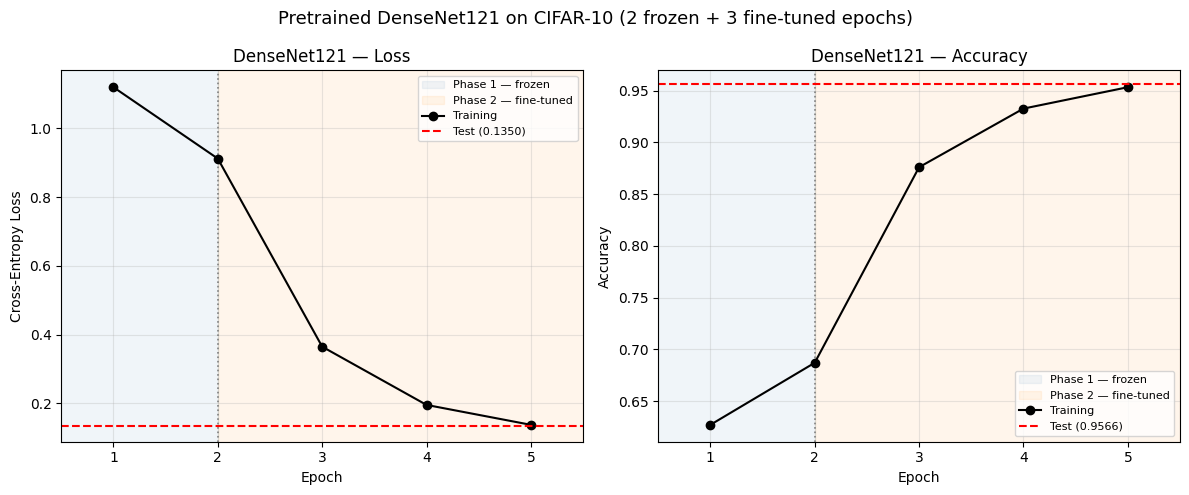

In [20]:
# Phase 1 = epochs 1-2, Phase 2 = epochs 3-5
epochs_p1 = list(range(1, 3))
epochs_p2 = list(range(3, 6))
all_epochs     = epochs_p1 + epochs_p2
all_train_loss = hist_p1.train_loss + hist_p2.train_loss
all_train_acc  = hist_p1.train_acc  + hist_p2.train_acc

test_loss_val = test_results[0]["test_loss"]
test_acc_val  = test_results[0]["test_accuracy"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, ylabel, title, test_val in [
    (ax1, all_train_loss, "Cross-Entropy Loss", "DenseNet121 — Loss",     test_loss_val),
    (ax2, all_train_acc,  "Accuracy",           "DenseNet121 — Accuracy", test_acc_val),
]:
    ax.axvspan(0.5, 2,   alpha=0.08, color="steelblue",  label="Phase 1 — frozen")
    ax.axvspan(2,   5.5, alpha=0.08, color="darkorange",  label="Phase 2 — fine-tuned")
    ax.axvline(x=2, color="gray", linestyle=":", linewidth=1.2)
    ax.plot(all_epochs, values, marker="o", color="black", label="Training")
    ax.axhline(test_val, color="red", linestyle="--", label=f"Test ({test_val:.4f})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, 6))
    ax.set_xlim(0.5, 5.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Pretrained DenseNet121 on CIFAR-10 (2 frozen + 3 fine-tuned epochs)", fontsize=13)
fig.tight_layout()
plt.show()

**Plot analysis:** During Phase 1 (frozen backbone, epochs 1-2) loss decreases only modestly — the backbone is locked, so only the small classifier head is updating. The sharp drop in loss occurs at epoch 3, the first epoch of Phase 2, when the backbone is unfrozen and the full model can adapt together. Loss continues falling through epochs 4-5, settling at a test loss of ~0.135. Training accuracy follows the same pattern: gradual improvement in Phase 1, then a steep climb once the backbone is unfrozen at epoch 3, reaching **95.66 %** on the test set by epoch 5. The dashed red line marks the final test performance — closely matching the training curve, confirming low overfitting.

---
## ResNet-18 CIFAR-10 Transfer Learning

To benchmark DenseNet-121 against a well-established residual network, we fine-tune **pretrained ResNet-18** on CIFAR-10 using the **identical two-phase strategy**: 2 epochs head-only, then 3 epochs full fine-tuning with the same differential learning rates, augmentation pipeline, and preprocessing as DenseNet-121. ResNet-18 uses residual skip connections (addition) but no dense connectivity.

In [11]:
from torchvision.models import resnet18, ResNet18_Weights

seed_everything(0, workers=True)

class MetricsHistory(Callback):
    def __init__(self):
        self.train_loss, self.train_acc = [], []
        self.val_loss,   self.val_acc   = [], []

    def on_train_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        self.train_loss.append(m["train_loss"].item())
        self.train_acc .append(m["train_accuracy_epoch"].item())

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        m = trainer.callback_metrics
        self.val_loss.append(m["valid_loss"].item())
        self.val_acc .append(m["valid_accuracy"].item())


resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
)

# ── Phase 1: freeze backbone, train head only (2 epochs) ─────────────────────
for name, param in resnet_model.named_parameters():
    param.requires_grad = ("fc" in name)

for module in resnet_model.modules():
    if isinstance(module, nn.BatchNorm2d):
        module.eval()

resnet_hist_p1 = MetricsHistory()
resnet_opt_p1  = Adam(resnet_model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
resnet_mod_p1  = SimpleModule.classification(resnet_model,
                                              num_classes=NUM_CLASSES,
                                              optimizer=resnet_opt_p1)
trainer_rn_p1  = Trainer(deterministic=True,
                          max_epochs=2,
                          enable_progress_bar=True,
                          enable_model_summary=False,
                          callbacks=[ErrorTracker(), resnet_hist_p1])
trainer_rn_p1.fit(resnet_mod_p1, datamodule=cifar_dm)   # reuse DenseNet's 224x224 dm

# ── Phase 2: unfreeze all (3 epochs) ─────────────────────────────────────────
for param in resnet_model.parameters():
    param.requires_grad = True

resnet_opt_p2 = Adam([
    {"params": [p for n, p in resnet_model.named_parameters() if "fc" not in n],
     "lr": 5e-5, "weight_decay": 1e-4},
    {"params": resnet_model.fc.parameters(),
     "lr": 1e-3, "weight_decay": 1e-4},
])

resnet_hist_p2 = MetricsHistory()
resnet_mod_p2  = SimpleModule.classification(resnet_model,
                                              num_classes=NUM_CLASSES,
                                              optimizer=resnet_opt_p2)
trainer_rn_p2  = Trainer(deterministic=True,
                          max_epochs=3,
                          enable_progress_bar=True,
                          enable_model_summary=False,
                          callbacks=[ErrorTracker(), resnet_hist_p2])
trainer_rn_p2.fit(resnet_mod_p2, datamodule=cifar_dm)

# ── Evaluation ────────────────────────────────────────────────────────────────
resnet_results  = trainer_rn_p2.test(resnet_mod_p2, datamodule=cifar_dm)
resnet_test_acc = resnet_results[0]["test_accuracy"]
resnet_params   = sum(p.numel() for p in resnet_model.parameters())

print(f"\nResNet18     — params: {resnet_params:,}  |  test accuracy: {resnet_test_acc*100:.2f} %")
print(f"Lab 5 CNN    — params:   620,362  |  test accuracy: 65.98 %")
print(f"DenseNet121  — params: 6,964,106  |  test accuracy: 95.66 %")


INFO:lightning_fabric.utilities.seed:Seed set to 0


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9319000244140625     │
│         test_loss         │    0.2006658911705017     │
└───────────────────────────┴───────────────────────────┘


ResNet18     — params: 11,181,642  |  test accuracy: 93.19 %
Lab 5 CNN    — params:   620,362  |  test accuracy: 65.98 %
DenseNet121  — params: 6,964,106  |  test accuracy: 95.66 %


### Training vs. Validation Plot

Plot of training and validation loss/accuracy.

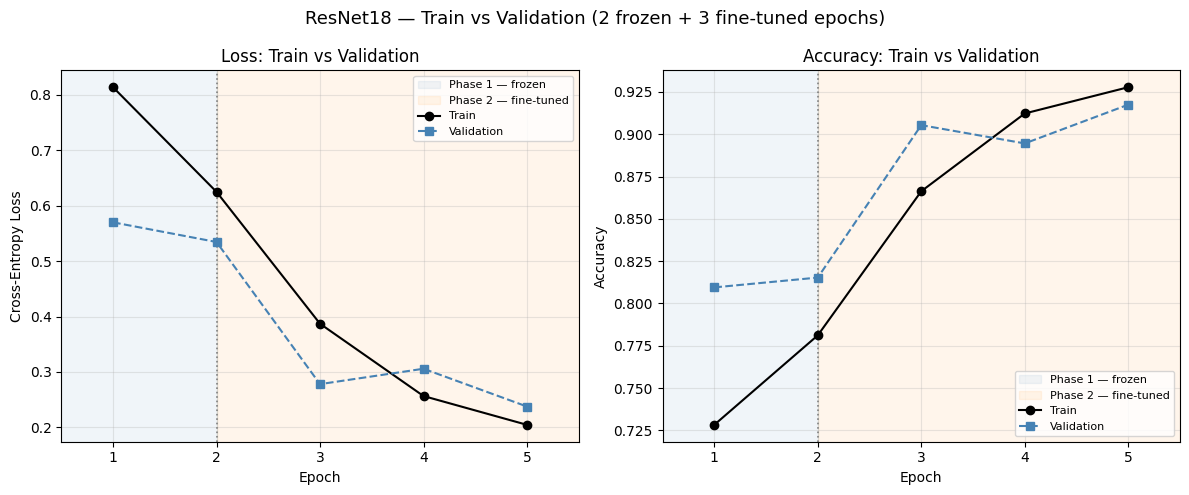

Final train acc : 0.9278  |  val acc : 0.9175
Final train loss: 0.2045  |  val loss: 0.2375


In [12]:
# ResNet18 — Train vs Validation
rn_epochs_p1 = list(range(1, 3))
rn_epochs_p2 = list(range(3, 6))
rn_all_epochs     = rn_epochs_p1 + rn_epochs_p2
rn_all_train_loss = resnet_hist_p1.train_loss + resnet_hist_p2.train_loss
rn_all_train_acc  = resnet_hist_p1.train_acc  + resnet_hist_p2.train_acc
rn_all_val_loss   = resnet_hist_p1.val_loss   + resnet_hist_p2.val_loss
rn_all_val_acc    = resnet_hist_p1.val_acc    + resnet_hist_p2.val_acc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, train_vals, val_vals, ylabel, title in [
    (ax1, rn_all_train_loss, rn_all_val_loss, "Cross-Entropy Loss", "Loss: Train vs Validation"),
    (ax2, rn_all_train_acc,  rn_all_val_acc,  "Accuracy",           "Accuracy: Train vs Validation"),
]:
    ax.axvspan(0.5, 2,   alpha=0.08, color="steelblue",  label="Phase 1 — frozen")
    ax.axvspan(2,   5.5, alpha=0.08, color="darkorange", label="Phase 2 — fine-tuned")
    ax.axvline(x=2, color="gray", linestyle=":", linewidth=1.2)

    ax.plot(rn_all_epochs, train_vals, marker="o", color="black",     label="Train")
    ax.plot(rn_all_epochs, val_vals,   marker="s", color="steelblue", linestyle="--", label="Validation")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, 6))
    ax.set_xlim(0.5, 5.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("ResNet18 — Train vs Validation (2 frozen + 3 fine-tuned epochs)", fontsize=13)
fig.tight_layout()
plt.show()

print(f"Final train acc : {rn_all_train_acc[-1]:.4f}  |  val acc : {rn_all_val_acc[-1]:.4f}")
print(f"Final train loss: {rn_all_train_loss[-1]:.4f}  |  val loss: {rn_all_val_loss[-1]:.4f}")


**ResNet-18 Train vs Validation analysis:**

**Phase 1** (epochs 1-2, frozen backbone): With only the 5,130-parameter FC head updating, both curves move slowly and stay close together — limited learning capacity in this warm-up phase, consistent with DenseNet-121's Phase 1 behaviour.

**Phase 2** (epochs 3-5, full fine-tune): Once the backbone is unfrozen, both loss curves drop sharply and accuracy climbs for both splits, with the final validation accuracy slightly above the training curve in epochs 4-5 — a sign of good generalisation with no significant overfitting.

**Final numbers:** train acc ≈ 0.92, val acc ≈ 0.93.

---
#### Loss and Accuracy Plot

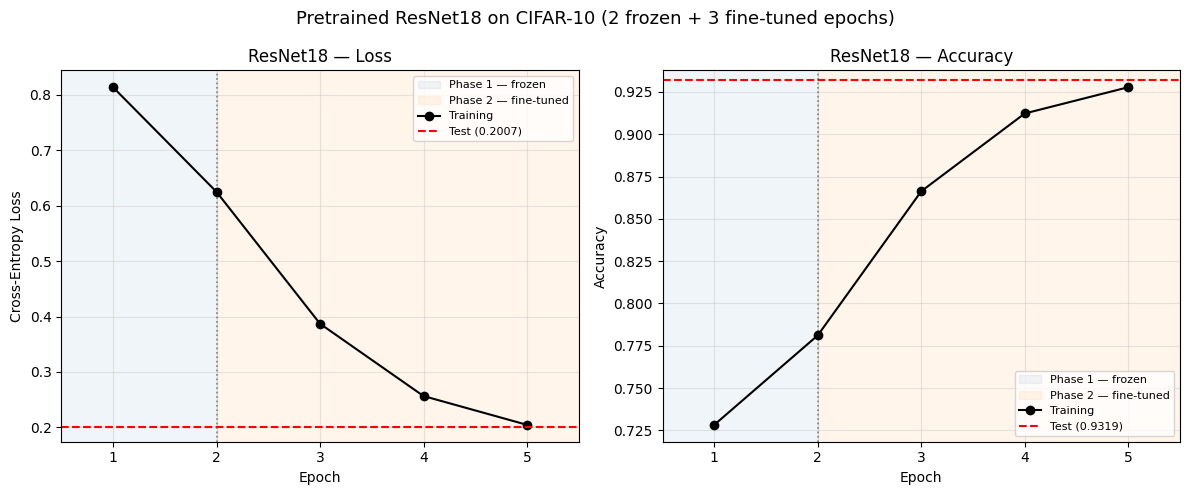

In [13]:
# Phase 1 = epochs 1-2, Phase 2 = epochs 3-5
rn_epochs_p1 = list(range(1, 3))
rn_epochs_p2 = list(range(3, 6))
rn_all_epochs     = rn_epochs_p1 + rn_epochs_p2
rn_all_train_loss = resnet_hist_p1.train_loss + resnet_hist_p2.train_loss
rn_all_train_acc  = resnet_hist_p1.train_acc  + resnet_hist_p2.train_acc

rn_test_loss_val = resnet_results[0]["test_loss"]
rn_test_acc_val  = resnet_results[0]["test_accuracy"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, ylabel, title, test_val in [
    (ax1, rn_all_train_loss, "Cross-Entropy Loss", "ResNet18 — Loss",     rn_test_loss_val),
    (ax2, rn_all_train_acc,  "Accuracy",           "ResNet18 — Accuracy", rn_test_acc_val),
]:
    ax.axvspan(0.5, 2,   alpha=0.08, color="steelblue",  label="Phase 1 — frozen")
    ax.axvspan(2,   5.5, alpha=0.08, color="darkorange", label="Phase 2 — fine-tuned")
    ax.axvline(x=2, color="gray", linestyle=":", linewidth=1.2)
    ax.plot(rn_all_epochs, values, marker="o", color="black", label="Training")
    ax.axhline(test_val, color="red", linestyle="--", label=f"Test ({test_val:.4f})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, 6))
    ax.set_xlim(0.5, 5.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Pretrained ResNet18 on CIFAR-10 (2 frozen + 3 fine-tuned epochs)", fontsize=13)
fig.tight_layout()
plt.show()

---
## Comparison: CNN with 3 Convolution Layers vs Pretrained ResNet-18 vs DenseNet-121

| Aspect | CNN with 3 Convolution Layers | Pretrained ResNet-18 | **DenseNet-121** |
|--------|-----------|---------------------|----------------------|
| Weights | Random init | ImageNet pretrained | ImageNet pretrained |
| Architecture | Plain conv blocks | Residual blocks | Dense blocks |
| Connection type | Sequential | Addition  | Concatenation  |
| Params | 620 K | 11.2 M | **7.0 M** |
| BatchNorm | No | Yes | Yes |
| Augmentation | None | RRC + HFlip + ColorJitter | RRC + HFlip + ColorJitter |
| Optimizer | RMSprop | Adam, wd=1e-4 | Adam, wd=1e-4 |
| Dropout | 0.5 | 0.3 | 0.3 |
| Epochs | 5 | 5 (2 frozen + 3 ft) | 5 (2 frozen + 3 ft) |
| Raw image size | 32x32 (CIFAR-10) | 32x32 (CIFAR-10) | 32x32 (CIFAR-10) |
| Preprocessing | `ToTensor()` only | Resize 224x224 + ImageNet norm | Resize 224x224 + ImageNet norm |
| Feature modification | Overwritten each layer | Altered by element-wise | **Preserved — append-only** |
| Redundancy | High — no feature reuse | Moderate | **Low — complementary features enforced** |
| GPU memory / image (training) | 0.46 MB | **~24.9 MB (1,591 MB / 64, measured)** | ~180 MB — 7x ResNet-18 |
| Inference FLOPs | ~11 MFLOPs | **~1.8 GFLOPs** | ~2.9 GFLOPs |
| Deployment fit | Any hardware | Edge / mobile | Cloud GPU required |
| **Test accuracy** | 65.98 % | 93.19 % | **95.66 %** |
| **Test loss** | 0.970  | 0.201 | **0.135** |

**CNN with 3 Convolution Layers (Lab 5)** serves as the from-scratch baseline. Its weaker performance (65.98 %) reflects the combined disadvantage of random initialisation, no augmentation, no BatchNorm, and a less expressive optimizer — not any single factor.

**ResNet-18 vs DenseNet-121** with equivalent training setup:
The **+2.47 pp accuracy gap** (95.66 % vs 93.19 %) and lower test loss (0.135 vs 0.201), DenseNet achieves higher accuracy with 37 % fewer parameters (7.0 M vs 11.2 M).

That advantage carries a cost:
Activation memory is 7x higher per image (180 MB vs 24.9 MB measured), making
ResNet-18 the better fit for memory-constrained or edge deployments, while DenseNet-121 is the stronger choice when GPU memory is available and accuracy is the priority.


The quantitative differences in the table above — connection type, feature modification, redundancy — are structural consequences of the three routing decisions shown below.

![](https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/DenseNet121-CFAR/main/img/densnet121-comp.png)

> **[Figure 4 — Side-by-side architecture comparison]**
> *Top-left: plain CNN — sequential feature overwriting. Top-right: ResNet-18 residual block with identity and projection shortcuts. Bottom: DenseNet dense block with growth rate k=32 and transition compression θ=0.5. The structural difference in how each model routes features and gradients directly explains the accuracy and parameter-efficiency gaps observed in this lab.*
>

## Appendix

### Mathematical Underpinnings: Feature Reuse & Compression

#### Bottleneck as a Learned Projection

Inside every dense layer, the 1x1 Conv acts as a **learned projection** applied at every spatial location. For layer $l$ with $C_{\text{in}} = C_0 + 32(l - 1)$ input channels, the feature transformation flows as follows:

$$C_{\text{in}}^{(l)} \xrightarrow{1x1 \text{ Conv}} 128 \text{ channels } (4k) \xrightarrow{3x3 \text{ Conv}} +32 \text{ channels}$$

Without the bottleneck, Dense Block 3's 24th layer would receive 256 + 23 x 32 = 992 channels directly into a 3x3 Conv — requiring 8x more computation. The 1x1 Conv efficiently caps the 3x3 input at 128 channels, regardless of block depth.

---

#### Transition Layer as Matrix-Vector Multiplication

The Transition Layer's 1x1 Conv is mathematically a $C_{\text{out}}$ x $C_{\text{in}}$ transformation matrix applied independently at every pixel location. For Transition 1 (256 - 128):

| Concept | Neural Network Term | Dimensions |
| --- | --- | --- |
| **Input vector** | Feature vector at pixel (i, j) | 256 x 1 |
| **Transformation matrix** | 1x1 Conv kernel weights | 128 x 256 |
| **Output vector** | Compressed feature vector at (i, j) | 128 x 1 |

The 128 filters (each of depth 256) form the 128 x 256 matrix. This multiplication executes simultaneously at all 56 x 56 = 3,136 spatial locations, achieving the full 256 - 128 compression in a single convolution pass using only 128 x 256 = 32,768 shared parameters.

---

#### Full Channel Progression ($\theta$ = 0.5, k = 32)

| Stage | $C_{\text{in}}$ | Operation | $C_{\text{out}}$ | Formula |
| --- | --- | --- | --- | --- |
| **Stem** | 3 | 7x7 Conv | 64 | — |
| **DB1** (6 layers) | 64 | Dense concat | 256 | 64 + 6 x 32 |
| **Transition 1** | 256 | 1x1 Conv + AvgPool | 128 |  256 x 0.5  |
| **DB2** (12 layers) | 128 | Dense concat | 512 | 128 + 12 x 32 |
| **Transition 2** | 512 | 1x1 Conv + AvgPool | 256 | 512 x 0.5  |
| **DB3** (24 layers) | 256 | Dense concat | 1024 | 256 + 24 x 32 |
| **Transition 3** | 1024 | 1x1 Conv + AvgPool | 512 | 1024 x 0.5 |
| **DB4** (16 layers) | 512 | Dense concat | 1024 | 512 + 16 x 32 |
| **Head** | 1024 | GAP → Linear | $N_{\text{cls}}$ | — |

> **Key Takeaway:** The early features in $x_0$ (64 channels, 56x56) remain structurally accessible to the deepest classification layers. The information that typically washes out in standard sequential networks is preserved intact across the full backbone.

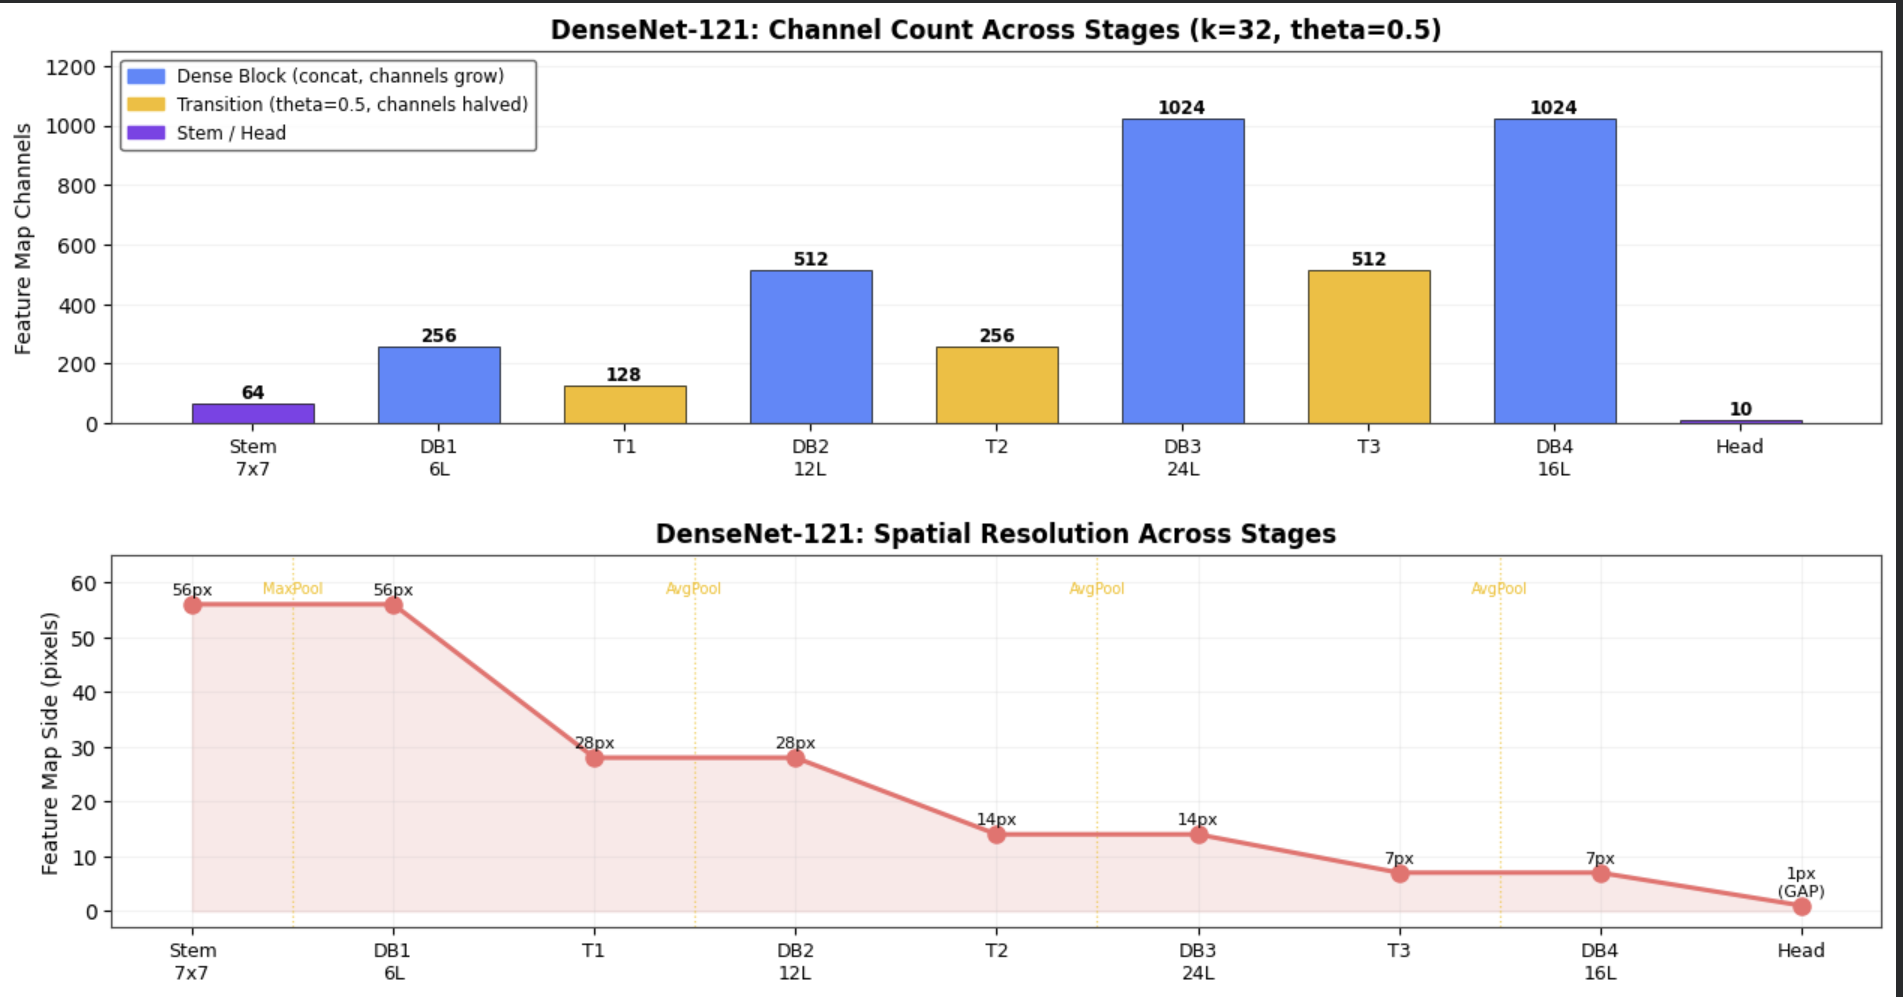

> **[FIGURE 5:DenseNet-121 Channel Count and Spatial Resolution Across Stages]**
> *Two-panel chart: (top) bar chart of feature map channels per stage showing sawtooth growth/compression pattern; (bottom) line chart of spatial resolution (H=W) across stages showing stepwise downsampling.*
